### Configure environment

In [ ]:
from fabrictestbed_extensions.fablib.fablib import FablibManager as fablib_manager
fablib = fablib_manager()
conf = fablib.show_config()

### Define configuration for this experiment

In [ ]:
slice_name="dualpi2-exps-v2" + fablib.get_bastion_username()

node_conf = [
 {'name': "tx_L4S",    'cores': 4, 'ram': 32, 'disk': 20, 'image': 'default_ubuntu_22', 'packages': ['iperf3', 'net-tools', 'moreutils','python3']},
 {'name': "tx_legacy",    'cores': 4, 'ram': 32, 'disk': 20, 'image': 'default_ubuntu_22', 'packages': ['iperf3', 'net-tools', 'moreutils','python3']},
 {'name': "router", 'cores': 4, 'ram': 32, 'disk': 20, 'image': 'default_ubuntu_22', 'packages': ['iperf3', 'net-tools', 'moreutils','python3']},
 {'name': "delay", 'cores': 4, 'ram': 32, 'disk': 20, 'image': 'default_ubuntu_22', 'packages': ['iperf3', 'net-tools', 'moreutils','python3']},
 {'name': "rx_L4S",    'cores': 4, 'ram': 32, 'disk': 20, 'image': 'default_ubuntu_22', 'packages': ['iperf3', 'net-tools', 'moreutils','python3']},
 {'name': "rx_legacy",    'cores': 4, 'ram': 32, 'disk': 20, 'image': 'default_ubuntu_22', 'packages': ['iperf3', 'net-tools', 'moreutils','python3']}
]
net_conf = [
 {"name": "net-tx", "subnet": "10.0.0.0/24", "nodes": [{"name": "tx_L4S",   "addr": "10.0.0.100"}, {"name": "tx_legacy",   "addr": "10.0.0.101"}, {"name": "delay", "addr": "10.0.0.2"}]},
 {"name": "net-delay-router", "subnet": "10.0.2.0/24", "nodes": [{"name": "delay",   "addr": "10.0.2.2"}, {"name": "router", "addr": "10.0.2.1"}]},
 {"name": "net-rx", "subnet": "10.0.5.0/24", "nodes": [{"name": "router",   "addr": "10.0.5.1"}, {"name": "rx_L4S", "addr": "10.0.5.100"}, {"name": "rx_legacy", "addr": "10.0.5.101"}]}

]
route_conf = [
 {"addr": "10.0.5.0/24", "gw": "10.0.0.2", "nodes": ["tx_L4S", "tx_legacy"]},
 {"addr": "10.0.5.0/24", "gw": "10.0.2.1", "nodes": ["delay"]},

 {"addr": "10.0.0.0/24", "gw": "10.0.5.1", "nodes": ["rx_L4S", "rx_legacy"]},
 {"addr": "10.0.0.0/24", "gw": "10.0.2.2", "nodes": ["router"]}

]
exp_conf = {'cores': sum([ n['cores'] for n in node_conf]), 'nic': sum([len(n['nodes']) for n in net_conf]) }

### Reserve resources

Now, we are ready to reserve resources!

First, make sure you don’t already have a slice with this name:

In [ ]:
try:
    slice = fablib.get_slice(slice_name)
    print("You already have a slice by this name!")
    print("If you previously reserved resources, skip to the 'log in to resources' section.")
except:
    print("You don't have a slice named %s yet." % slice_name)
    print("Continue to the next step to make one.")
    slice = fablib.new_slice(name=slice_name)

You already have a slice by this name!
If you previously reserved resources, skip to the 'log in to resources' section.


We will select a random site that has sufficient resources for our experiment:

In [ ]:
while True:
    site_name = fablib.get_random_site()
    if ( (fablib.resources.get_core_available(site_name) > 1.2*exp_conf['cores']) and
        (fablib.resources.get_component_available(site_name, 'SharedNIC-ConnectX-6') > 1.2**exp_conf['nic']) ):
        break

fablib.show_site(site_name)

Then we will add hosts and network segments:

In [ ]:
# this cell sets up the nodes
for n in node_conf:
    slice.add_node(name=n['name'], site=site_name,
                   cores=n['cores'],
                   ram=n['ram'],
                   disk=n['disk'],
                   image=n['image'])

In [ ]:
# this cell sets up the network segments
for n in net_conf:
    ifaces = [slice.get_node(node["name"]).add_component(model="NIC_Basic",
                                                 name=n["name"]).get_interfaces()[0] for node in n['nodes'] ]
    slice.add_l2network(name=n["name"], type='L2Bridge', interfaces=ifaces)

The following cell submits our request to the FABRIC site. The output of this cell will update automatically as the status of our request changes.

-   While it is being prepared, the “State” of the slice will appear as “Configuring”.
-   When it is ready, the “State” of the slice will change to “StableOK”.

You may prefer to walk away and come back in a few minutes (for simple slices) or a few tens of minutes (for more complicated slices with many resources).

In [ ]:
slice.submit()

In [ ]:
slice.get_state()
slice.wait_ssh(progress=True)

### Extend your slice

If you don’t plan to finish an experiment in one day, you can extend your slice. The following cell extends your reservation for 7 days.

In [ ]:
from datetime import datetime
from datetime import timezone
from datetime import timedelta

# Set end date to 7 days from now
end_date = (datetime.now(timezone.utc) + timedelta(days=7)).strftime("%Y-%m-%d %H:%M:%S %z")
slice.renew(end_date)

## We have reserved our slice and now we need to configure our nodes. ##

### Configure Experiment - Prague Kernel Installation

#### 6.6 Kernel

In [ ]:
for node in slice.get_nodes():
    # Download and unzip the kernel package
    node.execute("wget https://github.com/L4STeam/linux/releases/download/l4steam-6.6.y-build/l4s-l4steam-6.6.y.zip")
    node.execute("sudo apt install unzip")
    node.execute("unzip l4s-l4steam-6.6.y.zip")

    # Install the kernel packages and update GRUB
    node.execute("sudo dpkg --install debian_build/*")
    node.execute("sudo update-grub")
    node.execute("sudo reboot")

# wait for all nodes to come back up
slice.wait_ssh(progress=True)
for node in slice.get_nodes():
    # check kernel version
    node.execute("hostname; uname -a")

In [ ]:
#configuration for DUALPI2 bottleneck on the router
cmd_dualpi2="""sudo apt-get update
sudo apt -y install git gcc make bison flex libdb-dev libelf-dev pkg-config libbpf-dev libmnl-dev libcap-dev libatm1-dev selinux-utils libselinux1-dev
sudo git clone https://github.com/L4STeam/iproute2.git && cd iproute2
sudo ./configure
sudo make
sudo make install"""
slice.get_node(name="router").execute(cmd_dualpi2)
slice.get_node(name="router").execute("sudo modprobe sch_dualpi2")

In [ ]:
slice.get_node(name="router").execute("sudo modprobe sch_dualpi2")

In [ ]:
for node in slice.get_nodes():
    # check kernel version
    node.execute("hostname; uname -a")

### Configure resources

Next, we will configure the resources so they are ready to use.

In [ ]:
slice = fablib.get_slice(name=slice_name)

In [ ]:
# install packages
# this will take a while and will run in background while you do other steps
for n in node_conf:
    if len(n['packages']):
        node = slice.get_node(n['name'])
        pkg = " ".join(n['packages'])
        node.execute_thread("sudo apt update; sudo apt -y install %s" % pkg)

In [ ]:
# bring interfaces up and either assign an address (if there is one) or flush address
from ipaddress import ip_address, IPv4Address, IPv4Network

for net in net_conf:
    for n in net['nodes']:
        if_name = n['name'] + '-' + net['name'] + '-p1'
        iface = slice.get_interface(if_name)
        iface.ip_link_up()
        if n['addr']:
            iface.ip_addr_add(addr=n['addr'], subnet=IPv4Network(net['subnet']))
        else:
            iface.get_node().execute("sudo ip addr flush dev %s"  % iface.get_device_name())

In [ ]:
# prepare a "hosts" file that has names and addresses of every node
hosts_txt = [ "%s\t%s" % ( n['addr'], n['name'] ) for net in net_conf  for n in net['nodes'] if type(n) is dict and n['addr']]
for n in slice.get_nodes():
    for h in hosts_txt:
        n.execute("echo %s | sudo tee -a /etc/hosts" % h)

In [ ]:
# enable IPv4 forwarding on all nodes
for n in slice.get_nodes():
    n.execute("sudo sysctl -w net.ipv4.ip_forward=1")

net.ipv4.ip_forward = 1
net.ipv4.ip_forward = 1
net.ipv4.ip_forward = 1
net.ipv4.ip_forward = 1
net.ipv4.ip_forward = 1
net.ipv4.ip_forward = 1


In [ ]:
# set up static routes
for rt in route_conf:
    for n in rt['nodes']:
        slice.get_node(name=n).ip_route_add(subnet=IPv4Network(rt['addr']), gateway=rt['gw'])

In [ ]:
# turn off segmentation offload on interfaces
for iface in slice.get_interfaces():
    iface_name = iface.get_device_name()
    n = iface.get_node()
    offloads = ["gro", "lro", "gso", "tso"]
    for offload in offloads:
        n.execute("sudo ethtool -K %s %s off" % (iface_name, offload))

### Draw the network topology

The following cell will draw the network topology, for your reference. The interface name and addresses of each experiment interface will be shown on the drawing.

In [ ]:
l2_nets = [(n.get_name(), {'color': 'lavender'}) for n in slice.get_l2networks() ]
l3_nets = [(n.get_name(), {'color': 'pink'}) for n in slice.get_l3networks() ]
hosts   =   [(n.get_name(), {'color': 'lightblue'}) for n in slice.get_nodes()]
nodes = l2_nets + l3_nets + hosts
ifaces = [iface.toDict() for iface in slice.get_interfaces()]
edges = [(iface['network'], iface['node'],
          {'label': iface['physical_dev'] + '\n' + iface['ip_addr'] + '\n' + iface['mac']}) for iface in ifaces]

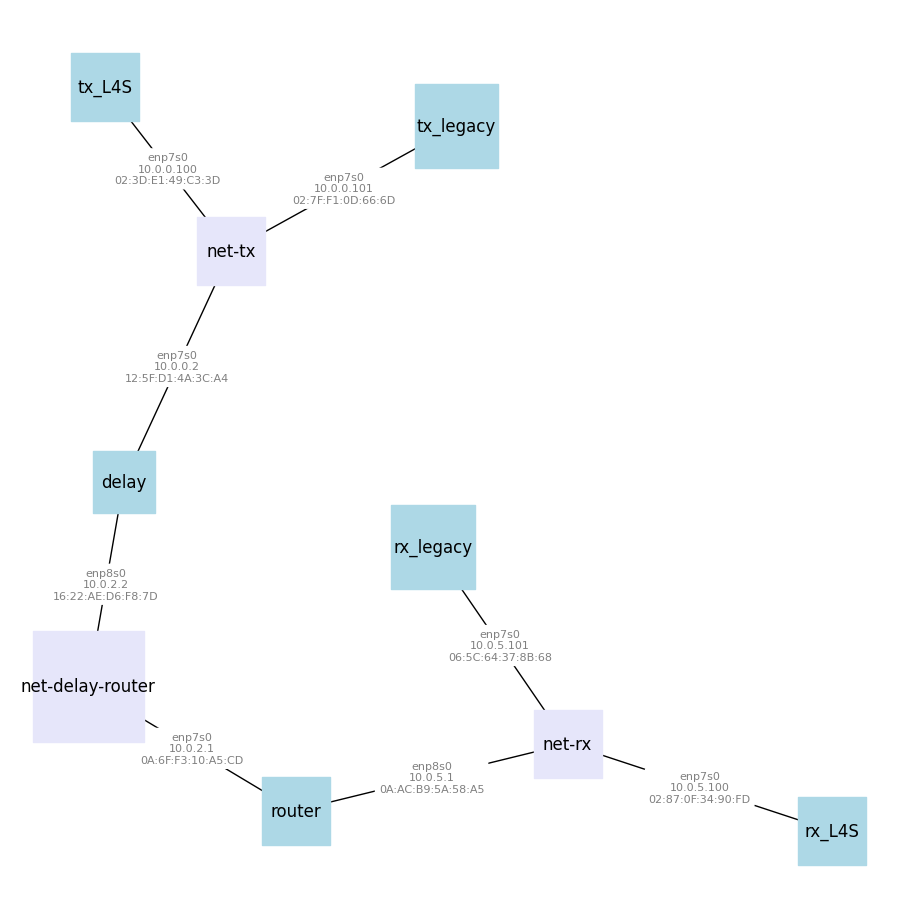

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
plt.figure(figsize=(len(nodes),len(nodes)))
G = nx.Graph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)
pos = nx.spring_layout(G)
nx.draw(G, pos, node_shape='s',
        node_color=[n[1]['color'] for n in nodes],
        node_size=[len(n[0])*400 for n in nodes],
        with_labels=True);
nx.draw_networkx_edge_labels(G,pos,
                             edge_labels=nx.get_edge_attributes(G,'label'),
                             font_color='gray',  font_size=8, rotate=False);

### Log into resources

Now, we are finally ready to log in to our resources over SSH! Run the following cells, and observe the table output - you will see an SSH command for each of the resources in your topology.

In [ ]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
slice_info = [{'Name': n.get_name(), 'SSH command': n.get_ssh_command()} for n in slice.get_nodes()]
pd.DataFrame(slice_info).set_index('Name')

Now, you can open an SSH session on any of the resources as follows:

-   in Jupyter, from the menu bar, use File \> New \> Terminal to open a new terminal.
-   copy an SSH command from the table, and paste it into the terminal. (Note that each SSH command is a single line, even if the display wraps the text to a second line! When you copy and paste it, paste it all together.)

You can repeat this process (open several terminals) to start a session on each resource. Each terminal session will have a tab in the Jupyter environment, so that you can easily switch between them.

## We have configured our nodes. Now, we can design and start our experiments.

### Execute Experiment

In [ ]:
# nodes and instances

tx_L4S_node = slice.get_node(name="tx_L4S")
tx_legacy_node = slice.get_node(name="tx_legacy")
rx_L4S_node = slice.get_node(name="rx_L4S")
rx_legacy_node = slice.get_node(name="rx_legacy")
delay_node = slice.get_node(name="delay")
router_node = slice.get_node(name="router")
# interfaces

tx_L4S_egress_iface  = tx_L4S_node.get_interface(network_name = "net-tx")
tx_legacy_egress_iface  = tx_legacy_node.get_interface(network_name = "net-tx")

delay_ingress_tx_iface  = delay_node.get_interface(network_name = "net-tx")
delay_egress_iface  = delay_node.get_interface(network_name = "net-delay-router")
delay_ingress_tx_name = delay_ingress_tx_iface.get_device_name()
delay_egress_name = delay_egress_iface.get_device_name()

router_ingress_iface  = router_node.get_interface(network_name = "net-delay-router")
router_egress_iface  = router_node.get_interface(network_name = "net-rx")
router_egress_name  = router_egress_iface.get_device_name()


rx_L4S_ingress_iface  = rx_L4S_node.get_interface(network_name = "net-rx")
rx_legacy_ingress_iface  = rx_legacy_node.get_interface(network_name = "net-rx")

## Priority Queue + CoDel Microbenchmark

Replaces the DualPI2 single-queue setup on the router with a **strict-priority
qdisc** that has two CoDel bands:

- **Band 1 (L4S, high priority)**: `prio 10:1 → 200 Mbps HTB cap → CoDel ce_threshold 1ms ecn`
- **Band 2 (classic, low priority)**: `prio 10:2 → CoDel target/ce_threshold 15ms ecn`

Classification uses **ECT(1)** in the IP ToS byte (set automatically by TCP-Prague),
so no DSCP marking is needed.

Sweeps L4S offered load against a fixed CUBIC classic load to characterize:

- L4S latency / throughput across regimes (below cap, at cap, above cap)
- CoDel marking behavior as L4S over-drives the priority allocation
- Isolation of classic traffic from L4S load changes


In [ ]:
# ============================================================
# Microbench: priority queue + CoDel — configuration
# ============================================================
# All knobs in one place. Lists are swept with itertools.product.
# ============================================================
import itertools, os

mb_exp_factors = {
    'l4s_per_stream_mbps':     [5, 9, 10, 12, 15],   # aggregate: 100, 180, 200, 240, 300 Mbps
    #'l4s_per_stream_mbps':     [5],   # aggregate: 100, 180, 200, 240, 300 Mbps
    'l4s_n_streams':           [20],
    'classic_per_stream_mbps': [100, 200],
    'classic_n_streams':       [5],
    'btl_capacity_mbps':       [1000],               # router HTB rate (link rate)
    'l4s_cap_mbps':            [200],                # L4S priority allocation (TBF)
    'base_rtt_ms':             [30],
    'duration_s':              [60],
    'trial':                   [1,2,3,4,5],
}

mb_factor_names = list(mb_exp_factors.keys())
mb_exp_list = []
for combo in itertools.product(*mb_exp_factors.values()):
    e = dict(zip(mb_factor_names, combo))
    e['l4s_aggregate_mbps']     = e['l4s_per_stream_mbps']     * e['l4s_n_streams']
    e['classic_aggregate_mbps'] = e['classic_per_stream_mbps'] * e['classic_n_streams']
    mb_exp_list.append(e)

def mb_build_name(e):
    return (f"microbench_pqdpi_"
            f"L4S{e['l4s_n_streams']}x{e['l4s_per_stream_mbps']}M_"
            f"cls{e['classic_n_streams']}x{e['classic_per_stream_mbps']}M_"
            f"cap{e['l4s_cap_mbps']}M_link{e['btl_capacity_mbps']}M_"
            f"rtt{e['base_rtt_ms']}ms_t{e['trial']}")

MB_REMOTE_DIR = "/home/ubuntu"
MB_LOCAL_DIR  = "/home/fabric/work/DualPI2-Modifications-Exps/microbench-pqdpi-results"
os.makedirs(MB_LOCAL_DIR, exist_ok=True)

print(f"Microbench plan: {len(mb_exp_list)} trials")
for i, e in enumerate(mb_exp_list):
    print(f"  {i+1:2d}. L4S agg={e['l4s_aggregate_mbps']:4d}M  "
          f"cls={e['classic_aggregate_mbps']}M  trial={e['trial']}  -> {mb_build_name(e)}")


In [ ]:
# ============================================================
# Router qdisc: strict priority + capped L4S class + CoDel
# ============================================================
# htb 1: root (rate=link_mbps)
#   └─ prio 10: (3 bands)
#       ├─ 10:1 (L4S, high priority)
#       │   └─ htb 100: rate L4S_CAP
#       │       └─ codel 101: ce_threshold 1ms, ECN
#       └─ 10:2 (classic, low priority)
#           └─ codel 201: target/ce_threshold 15ms, ECN
#
# Classifier: ECT(1) → flowid 10:1
#   ECT(1) means low 2 bits of ToS == 01.
#   TCP-Prague (-C prague) sets ECT(1) automatically.
#   CUBIC (-C cubic) leaves the ECN bits at 00 → falls through to band 2.
# ============================================================

def mb_setup_router(dev, link_mbps, l4s_cap_mbps):

    cmd = (
    f"sudo tc qdisc del dev {dev} root 2>/dev/null; "

    f"sudo tc qdisc add dev {dev} root handle 1: htb default 1; "
    f"sudo tc class add dev {dev} parent 1: classid 1:1 htb "
    f"rate {link_mbps}mbit ceil {link_mbps}mbit "
    f"burst 128kb cburst 128kb; "

    f"sudo tc qdisc add dev {dev} parent 1:1 handle 10: prio bands 3 "
    f"priomap 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1; "

    f"sudo tc qdisc add dev {dev} parent 10:1 handle 100: htb default 1; "
    f"sudo tc class add dev {dev} parent 100: classid 100:1 htb "
    f"rate {l4s_cap_mbps}mbit ceil {l4s_cap_mbps}mbit "
    f"burst 25kb cburst 25kb; "

    #f"sudo tc qdisc add dev {dev} parent 100:1 handle 101: dualpi2 "
    #f"limit 1000 step_thresh 1ms target 100ms any_ect; "

    f"sudo tc qdisc add dev {dev} parent 100:1 handle 101: codel "
    f"limit 1000 target 100ms interval 1s ecn ce_threshold 1ms; "

    f"sudo tc qdisc add dev {dev} parent 10:2 handle 201: codel "
    f"limit 20000 target 15ms interval 100ms ecn ce_threshold 15ms; "

    f"sudo tc filter add dev {dev} parent 10: protocol ip prio 1 flower "
    f"ip_tos 0x01/0x03 classid 10:1; "
    f"sudo tc filter add dev {dev} parent 10: protocol ip prio 2 flower "
    f"ip_tos 0x03/0x03 classid 10:1; "
    f"sudo tc filter add dev {dev} parent 10: protocol ipv6 prio 3 flower "
    f"ip_tos 0x01/0x03 classid 10:1; "
    f"sudo tc filter add dev {dev} parent 10: protocol ipv6 prio 4 flower "
    f"ip_tos 0x03/0x03 classid 10:1"
)

    router_node.execute(cmd, quiet=True)

# One-time sanity check (apply + dump current state)
_e0 = mb_exp_list[0]
mb_setup_router(router_egress_name, _e0['btl_capacity_mbps'], _e0['l4s_cap_mbps'])
out, _ = router_node.execute(f"sudo tc -s qdisc show dev {router_egress_name}")
print(out)


In [ ]:
# ============================================================
# Microbench runner — concurrent L4S (Prague) + classic (CUBIC)
# ============================================================
# - tx_L4S    → rx_L4S    @ 10.0.5.100:4000  (-C prague)
# - tx_legacy → rx_legacy @ 10.0.5.101:5000  (-C cubic)
# - L4S blocks the loop; classic runs threaded
# - Resume-skip: presence of *_l4s.json on tx_L4S
# - Router qdisc state snapshotted before and after each trial
# ============================================================
import time

for idx, e in enumerate(mb_exp_list):
    name    = mb_build_name(e)
    f_l4s   = f"{name}_l4s.json"
    f_cls   = f"{name}_classic.json"
    f_qpre  = f"{name}_qdisc_pre.txt"
    f_qpost = f"{name}_qdisc_post.txt"

    # Skip if already done
    out, _ = tx_L4S_node.execute(f"ls {f_l4s}", quiet=True)
    if out.strip():
        print(f"[{idx+1}/{len(mb_exp_list)}] already have {name}, skipping")
        continue

    print(f"[{idx+1}/{len(mb_exp_list)}] running: {name}")

    # CC modules + ECN settings
    tx_L4S_node.execute("sudo modprobe tcp_prague; "
                        "sudo sysctl -w net.ipv4.tcp_congestion_control=prague; "
                        "sudo sysctl -w net.ipv4.tcp_ecn=3", quiet=False)
    rx_L4S_node.execute("sudo sysctl -w net.ipv4.tcp_ecn=3", quiet=False)
    tx_legacy_node.execute("sudo modprobe tcp_cubic; "
                           "sudo sysctl -w net.ipv4.tcp_ecn=0", quiet=False)
    rx_legacy_node.execute("sudo sysctl -w net.ipv4.tcp_ecn=0", quiet=False)

    # Delay (RTT)
    for d_dev in [delay_ingress_tx_name, delay_egress_name]:
        delay_node.execute(
            f"sudo tc qdisc replace dev {d_dev} root netem "
            f"delay {e['base_rtt_ms']/2}ms limit 1000000",
            quiet=True)

    # Router qdisc
    mb_setup_router(router_egress_name, e['btl_capacity_mbps'], e['l4s_cap_mbps'])

    # Pre-trial qdisc snapshot
    router_node.execute(
        f"sudo tc -s qdisc show dev {router_egress_name} > {f_qpre}",
        quiet=True)

    # iperf3 servers (one-shot, daemonized)
    rx_L4S_node.execute("killall iperf3 2>/dev/null; true", quiet=False)
    rx_legacy_node.execute("killall iperf3 2>/dev/null; true", quiet=False)
    rx_L4S_node.execute("iperf3 -s -1 -p 4000 -D", quiet=False)
    rx_legacy_node.execute("iperf3 -s -1 -p 5000 -D", quiet=False)
    time.sleep(1)

    # Classic in background (threaded); L4S in foreground (blocks)
    tx_legacy_node.execute_thread(
        f"iperf3 -c 10.0.5.101 -p 5000 -C cubic "
        f"-P {e['classic_n_streams']} -b {e['classic_per_stream_mbps']}M "
        f"-t {e['duration_s']} -J > {f_cls}"
    )
    tx_L4S_node.execute(
        f"sleep 1; iperf3 -c 10.0.5.100 -p 4000 -C prague "
        f"-P {e['l4s_n_streams']} -b {e['l4s_per_stream_mbps']}M "
        f"-t {e['duration_s'] - 1} -J > {f_l4s}"
    )

    time.sleep(3)

    # Post-trial qdisc snapshot
    router_node.execute(
        f"sudo tc -s qdisc show dev {router_egress_name} > {f_qpost}",
        quiet=True)

    print(f"  done: {name}")

print(f"All {len(mb_exp_list)} microbench trials finished.")


In [ ]:
# ============================================================
# Microbench analysis — download outputs, compute per-trial metrics
# ============================================================
# Reads:
#   {name}_l4s.json        (iperf3 -J L4S sender)
#   {name}_classic.json    (iperf3 -J classic sender)
#   {name}_qdisc_pre.txt   (tc -s qdisc show, before the trial)
#   {name}_qdisc_post.txt  (tc -s qdisc show, after the trial)
# Builds:
#   mb_df   — one row per trial
#   mb_agg  — one row per L4S offered level (mean ± std across trials)
# ============================================================
import json, re, os
import pandas as pd
import numpy as np

# Steady-state window (used for sender-side interval averaging only)
MB_T_START = 10.0
MB_T_END   = 55.0

def mb_download(node, fname):
    local = os.path.join(MB_LOCAL_DIR, fname)
    if os.path.exists(local) and os.path.getsize(local) > 0:
        return local
    try:
        node.download_file(local, f"{MB_REMOTE_DIR}/{fname}")
    except Exception as ex:
        print(f"  [WARN] {fname}: {ex}")
        return None
    return local if (os.path.exists(local) and os.path.getsize(local) > 0) else None

def mb_parse_iperf(path, t_start=MB_T_START, t_end=MB_T_END):
    """
    Returns goodput from TWO views:
      - rx_goodput_mbps  : receiver-side, overall (true goodput, no retrans)
      - tx_rate_mbps     : sender-side rate within steady-state window (for QA)
    """
    if not path: return None
    try:
        d = json.load(open(path))
    except Exception as ex:
        print(f"  [WARN] bad JSON {path}: {ex}")
        return None

    end       = d.get('end', {})
    streams   = end.get('streams', [])
    sum_sent  = end.get('sum_sent', end.get('sum', {}))
    sum_recv  = end.get('sum_received', {})

    # === PRIMARY: receiver-side overall goodput ===
    # Aggregate from end.sum_received (true goodput, excludes retransmissions)
    rx_total_bytes = sum_recv.get('bytes', 0)
    rx_total_sec   = sum_recv.get('seconds', 0) or sum_sent.get('seconds', 1)
    rx_goodput_mbps = (rx_total_bytes * 8 / rx_total_sec / 1e6) if rx_total_sec > 0 else 0.0

    # Per-stream receiver goodput (for sanity / breakdown)
    per_stream_rx = []
    for s in streams:
        r = s.get('receiver', {})
        if r.get('bits_per_second') is not None:
            per_stream_rx.append(r['bits_per_second'] / 1e6)

    # === SECONDARY: sender-side steady-state windowed rate ===
    # Useful for QA — confirms the offered rate matched the target during steady state
    rates_window = []
    for iv in d.get('intervals', []):
        s = iv.get('sum', {})
        st = s.get('start')
        if st is None: continue
        if t_start <= st < t_end:
            rates_window.append(s.get('bits_per_second', 0) / 1e6)
    tx_rate_mbps = float(np.mean(rates_window)) if rates_window else 0.0

    # Per-stream sender RTT (microseconds → ms)
    mean_rtts = [s.get('sender', {}).get('mean_rtt', 0)/1000 for s in streams]
    max_rtts  = [s.get('sender', {}).get('max_rtt',  0)/1000 for s in streams]

    return dict(
        rx_goodput_mbps  = rx_goodput_mbps,        # PRIMARY metric
        tx_rate_mbps     = tx_rate_mbps,           # sender-side QA
        per_stream_rx    = per_stream_rx,
        total_retrans    = sum_sent.get('retransmits', 0),
        mean_rtt_ms      = float(np.mean(mean_rtts)) if mean_rtts else 0,
        max_rtt_ms       = float(np.mean(max_rtts))  if max_rtts  else 0,
        n_streams        = len(streams),
        cc               = end.get('sender_tcp_congestion', ''),
    )

def mb_parse_dualpi2(text, handle):
    """Parse 'qdisc dualpi2 {handle}: ...' block (used for L4S band)."""
    m = re.search(rf'qdisc dualpi2 {handle}:.*?(?=\nqdisc|\Z)', text, re.S)
    if not m: return None
    body = m.group(0)
    def grab(pat, default=0):
        mm = re.search(pat, body)
        return int(mm.group(1)) if mm else default
    return dict(
        sent_bytes  = grab(r'Sent (\d+) bytes'),
        dropped     = grab(r'\(dropped (\d+),'),    # from the parens line
        pkts_in_l   = grab(r'pkts_in_l (\d+)'),     # L4S packets entering L-queue
        pkts_in_c   = grab(r'pkts_in_c (\d+)'),     # classic packets (should be ~0)
        maxq        = grab(r'maxq (\d+)'),
        ecn_mark    = grab(r'ecn_mark (\d+)'),      # total marks (step + PI ramp)
        step_mark   = grab(r'step_mark (\d+)'),     # step-only marks
    )

mb_rows = []
for e in mb_exp_list:
    name = mb_build_name(e)
    f_l4s   = mb_download(tx_L4S_node,    f"{name}_l4s.json")
    f_cls   = mb_download(tx_legacy_node, f"{name}_classic.json")
    f_qpre  = mb_download(router_node,    f"{name}_qdisc_pre.txt")
    f_qpost = mb_download(router_node,    f"{name}_qdisc_post.txt")

    l4s = mb_parse_iperf(f_l4s) or {}
    cls = mb_parse_iperf(f_cls) or {}

    pre_txt  = open(f_qpre).read()  if f_qpre  else ''
    post_txt = open(f_qpost).read() if f_qpost else ''

    # L4S band: DualPI2 (handle 101)
    pre_l4s  = mb_parse_dualpi2(pre_txt,  '101') or dict(pkts_in_l=0, pkts_in_c=0, dropped=0,
                                                         ecn_mark=0, step_mark=0, maxq=0)
    post_l4s = mb_parse_dualpi2(post_txt, '101') or pre_l4s

    # Deltas over the trial
    d_l4s_pkts = max(1, post_l4s['pkts_in_l'] - pre_l4s['pkts_in_l'])

    d_l4s_marks_total = post_l4s['ecn_mark']  - pre_l4s['ecn_mark']
    d_l4s_marks_step  = post_l4s['step_mark'] - pre_l4s['step_mark']
    d_l4s_drops       = post_l4s['dropped']   - pre_l4s['dropped']
    d_l4s_leak_c      = post_l4s['pkts_in_c'] - pre_l4s['pkts_in_c']   # should be ~0
    l4s_maxq_post     = post_l4s['maxq']                                # peak over trial

    mb_rows.append({
        'trial':                 e['trial'],
        'base_rtt_ms':           e['base_rtt_ms'],
        'l4s_per_stream_mbps':   e['l4s_per_stream_mbps'],
        'l4s_offered_mbps':      e['l4s_aggregate_mbps'],
        'classic_offered_mbps':  e['classic_aggregate_mbps'],
        'l4s_cap_mbps':          e['l4s_cap_mbps'],

        # === L4S delivered (receiver-side primary, sender-side secondary) ===
        'l4s_goodput_mbps':      l4s.get('rx_goodput_mbps', 0),    # PRIMARY: rx
        'l4s_tx_rate_mbps':      l4s.get('tx_rate_mbps', 0),       # QA: sender steady-state
        'l4s_total_retrans':     l4s.get('total_retrans', 0),
        'l4s_mean_rtt_ms':       l4s.get('mean_rtt_ms', 0),
        'l4s_max_rtt_ms':        l4s.get('max_rtt_ms', 0),
        'l4s_cc':                l4s.get('cc', ''),

        # === Classic delivered ===
        'classic_goodput_mbps':  cls.get('rx_goodput_mbps', 0),    # PRIMARY: rx
        'classic_tx_rate_mbps':  cls.get('tx_rate_mbps', 0),
        'classic_total_retrans': cls.get('total_retrans', 0),
        'classic_mean_rtt_ms':   cls.get('mean_rtt_ms', 0),
        'classic_max_rtt_ms':    cls.get('max_rtt_ms', 0),
        'classic_cc':            cls.get('cc', ''),

        # === DualPI2 (L4S band, handle 101) counters — deltas over the trial ===
        'dpi2_l4s_mark_pct':       100 * d_l4s_marks_total / d_l4s_pkts,
        'dpi2_l4s_step_mark_pct':  100 * d_l4s_marks_step  / d_l4s_pkts,
        'dpi2_l4s_drop_pct':       100 * d_l4s_drops       / d_l4s_pkts,
        'dpi2_l4s_maxq_pkts':      l4s_maxq_post,
        'dpi2_l4s_leak_to_c_pkts': d_l4s_leak_c,                    # should be 0
    })

mb_df = pd.DataFrame(mb_rows)
print(f"Loaded {len(mb_df)} microbench trials. Window (sender-side QA only): [{MB_T_START}, {MB_T_END}] s\n")

# Aggregate per L4S offered level (mean + std across trials)
mb_agg = mb_df.groupby('l4s_offered_mbps', as_index=False).agg(
    l4s_goodput_mean       = ('l4s_goodput_mbps',       'mean'),
    l4s_goodput_std        = ('l4s_goodput_mbps',       'std'),
    l4s_tx_rate_mean       = ('l4s_tx_rate_mbps',       'mean'),
    l4s_mean_rtt_mean      = ('l4s_mean_rtt_ms',        'mean'),
    l4s_max_rtt_mean       = ('l4s_max_rtt_ms',         'mean'),
    l4s_retrans_mean       = ('l4s_total_retrans',      'mean'),

    classic_goodput_mean   = ('classic_goodput_mbps',   'mean'),
    classic_goodput_std    = ('classic_goodput_mbps',   'std'),
    classic_mean_rtt_mean  = ('classic_mean_rtt_ms',    'mean'),
    classic_retrans_mean   = ('classic_total_retrans',  'mean'),

    dpi2_mark_mean         = ('dpi2_l4s_mark_pct',      'mean'),
    dpi2_step_mark_mean    = ('dpi2_l4s_step_mark_pct', 'mean'),
    dpi2_drop_mean         = ('dpi2_l4s_drop_pct',      'mean'),
    dpi2_maxq_mean         = ('dpi2_l4s_maxq_pkts',     'mean'),
    dpi2_leak_to_c_mean    = ('dpi2_l4s_leak_to_c_pkts','mean'),

    n_trials               = ('trial',                  'count'),
).sort_values('l4s_offered_mbps').reset_index(drop=True)

# Save CSVs
mb_csv     = os.path.join(MB_LOCAL_DIR, "microbench_per_trial.csv")
mb_agg_csv = os.path.join(MB_LOCAL_DIR, "microbench_aggregated.csv")
mb_df.to_csv(mb_csv,     index=False)
mb_agg.to_csv(mb_agg_csv, index=False)
print(f"Wrote {mb_csv}")
print(f"Wrote {mb_agg_csv}\n")

try:
    display(mb_df)
    display(mb_agg)
except NameError:
    print(mb_df.to_string())
    print(mb_agg.to_string())

Saved: /home/fabric/work/DualPI2-Modifications-Exps/microbench-pqdpi-results/mb_combined.pdf


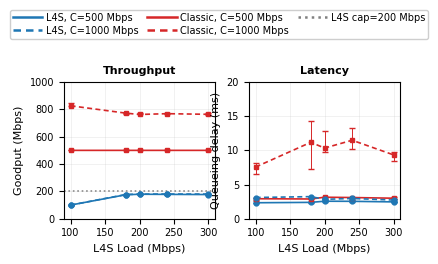

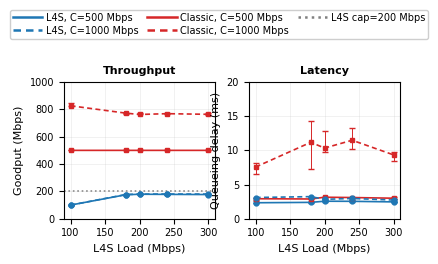

In [ ]:
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# =====================================================================
# STYLE — everything tunable lives here
# =====================================================================
MB_STYLE = {
    # Figure
    'figsize':      (3.7, 2.4),   # single column width ~3.5 in
    'wspace':       0.30,         # gap between Throughput / Latency panels
    'tight_rect':   (0, 0, 1, 0.82),  # reserve top space for legend
    'save_pad':     0.03,

    # Fonts
    'title_fs':     8,
    'title_bold':   True,
    'axes_label_fs':8,
    'tick_fs':      7,


    #'margin_left':   0.09,   # was 0.11 — pull left edge in
    'margin_right':  0.99,   # was 0.98 — push right edge out
    #'wspace':        0.35,   # was 0.55 — smaller gap between panels

    'wspace':       0.22,   # was 0.35 — biggest gain; smaller gap between panels
    'margin_left':  0.08,   # was 0.09


    'margin_bottom': 0.21,   # space for x-axis label


    # Curves
    'line_lw':      1.2,
    'marker_size':  3.5,
    'capsize':      2.0,
    'elinewidth':   0.7,
    'l4s_color':    'tab:blue',
    'cls_color':    'tab:red',
    'l4s_marker':   'o',
    'cls_marker':   's',
    'group_linestyles': ['-', (0, (3, 2))],   # solid, then dashed

    # Cap line
    'cap_color':    'gray',
    'cap_ls':       ':',
    'cap_lw':       1.2,

    # Y limits
    'tp_ylim':      (0, 1000),
    'lat_ylim':     (0, 20),

    # Grid
    'grid_alpha':   0.30,
    'grid_lw':      0.4,

    # Legend (above both panels)
    'legend_fs':            7,
    'legend_ncol':          3,        # wraps to 2 rows (5 entries / 3 cols)
    'legend_handlelength':  3.0,
    'legend_handletextpad': 0.4,
    'legend_columnspacing': 0.9,
    'legend_labelspacing':  0.3,
    'legend_borderpad':     0.3,
    'legend_handle_lw':     1.8,
    'legend_frameon':       True,
    'legend_framealpha':    0.95,

    'margin_top':       0.78,   # was 0.82 — leaves more room above the title
    'legend_y_anchor':  1.10,   # was 1.00 — lifts the legend above the figure

    # Legend label templates (compact for single column)
    'lbl_l4s':       'L4S, C={C} Mbps',
    'lbl_classic':   'Classic, C={C} Mbps',
    'lbl_cap':       'L4S cap={cap} Mbps',
}


def mb_grouped_stats(df, x_col, y_col):
    g = df.groupby(x_col)[y_col]
    return (g.mean().index.tolist(),
            g.mean().values.tolist(),
            g.quantile(0.25).values.tolist(),
            g.quantile(0.75).values.tolist())


def mb_errorbar_nolegend(ax, df, x_col, y_col, color, marker, linestyle, S):
    xs, means, q25, q75 = mb_grouped_stats(df, x_col, y_col)
    yerr_lo = [max(0.0, m - q) for m, q in zip(means, q25)]
    yerr_hi = [max(0.0, q - m) for q, m in zip(q75, means)]
    ax.errorbar(xs, means, yerr=[yerr_lo, yerr_hi],
                marker=marker, color=color,
                linewidth=S['line_lw'], markersize=S['marker_size'],
                capsize=S['capsize'], elinewidth=S['elinewidth'],
                linestyle=linestyle, label='_nolegend_')


def _style_panel(ax, title, xlabel, ylabel, ylim, S):
    ax.set_title(title, fontsize=S['title_fs'],
                 fontweight='bold' if S['title_bold'] else 'normal')
    ax.set_xlabel(xlabel, fontsize=S['axes_label_fs'])
    ax.set_ylabel(ylabel, fontsize=S['axes_label_fs'])
    ax.tick_params(axis='both', labelsize=S['tick_fs'])
    ax.grid(alpha=S['grid_alpha'], linewidth=S['grid_lw'])
    ax.ticklabel_format(axis='both', style='plain', useOffset=False)
    ax.set_ylim(*ylim)


def plot_microbench_combined(mb_df, save_path,
                             base_rtt_ms=30,
                             x_col='l4s_offered_mbps',
                             group_col='classic_offered_mbps',
                             style=None):
    S = {**MB_STYLE, **(style or {})}

    df = mb_df.copy()
    df['l4s_q_delay_ms']     = (df['l4s_mean_rtt_ms']     - base_rtt_ms).clip(lower=0)
    df['classic_q_delay_ms'] = (df['classic_mean_rtt_ms'] - base_rtt_ms).clip(lower=0)

    groups = sorted(df[group_col].unique())
    group_ls = {g: S['group_linestyles'][i % len(S['group_linestyles'])]
                for i, g in enumerate(groups)}

    fig, (ax_tp, ax_lat) = plt.subplots(1, 2, figsize=S['figsize'])
    #fig.subplots_adjust(wspace=S['wspace'])

    fig.subplots_adjust(left=S['margin_left'],
                    right=S['margin_right'],
                    top=S['margin_top'],
                    bottom=S['margin_bottom'],
                    wspace=S['wspace'])

    # ---- Throughput ----
    for g in groups:
        sub = df[df[group_col] == g]
        mb_errorbar_nolegend(ax_tp, sub, x_col, 'l4s_goodput_mbps',
                             S['l4s_color'], S['l4s_marker'], group_ls[g], S)
        mb_errorbar_nolegend(ax_tp, sub, x_col, 'classic_goodput_mbps',
                             S['cls_color'], S['cls_marker'], group_ls[g], S)

    cap = None
    if 'l4s_cap_mbps' in df.columns:
        cap = int(df['l4s_cap_mbps'].mode().iloc[0])
        ax_tp.axhline(cap, color=S['cap_color'], linestyle=S['cap_ls'],
                      linewidth=S['cap_lw'], alpha=0.9)

    _style_panel(ax_tp, 'Throughput', 'L4S Load (Mbps)', 'Goodput (Mbps)',
                 S['tp_ylim'], S)

    # ---- Latency ----
    for g in groups:
        sub = df[df[group_col] == g]
        mb_errorbar_nolegend(ax_lat, sub, x_col, 'l4s_q_delay_ms',
                             S['l4s_color'], S['l4s_marker'], group_ls[g], S)
        mb_errorbar_nolegend(ax_lat, sub, x_col, 'classic_q_delay_ms',
                             S['cls_color'], S['cls_marker'], group_ls[g], S)

    _style_panel(ax_lat, 'Latency', 'L4S Load (Mbps)', 'Queueing delay (ms)',
                 S['lat_ylim'], S)

    # ---- Shared legend above both panels ----
    handles = []
    for g in groups:
        handles.append(Line2D([0], [0], color=S['l4s_color'],
                              linestyle=group_ls[g],
                              linewidth=S['legend_handle_lw'],
                              label=S['lbl_l4s'].format(C=int(g))))
    for g in groups:
        handles.append(Line2D([0], [0], color=S['cls_color'],
                              linestyle=group_ls[g],
                              linewidth=S['legend_handle_lw'],
                              label=S['lbl_classic'].format(C=int(g))))
    if cap is not None:
        handles.append(Line2D([0], [0], color=S['cap_color'],
                              linestyle=S['cap_ls'],
                              linewidth=S['legend_handle_lw'],
                              label=S['lbl_cap'].format(cap=cap)))

    fig.legend(handles=handles,
               loc='upper center',
               bbox_to_anchor=(0.5, S['legend_y_anchor']),
               fontsize=S['legend_fs'],
               ncol=S['legend_ncol'],
               handlelength=S['legend_handlelength'],
               handletextpad=S['legend_handletextpad'],
               columnspacing=S['legend_columnspacing'],
               labelspacing=S['legend_labelspacing'],
               borderpad=S['legend_borderpad'],
               frameon=S['legend_frameon'],
               framealpha=S['legend_framealpha'])

    #fig.tight_layout(rect=S['tight_rect'])
    fig.savefig(save_path, bbox_inches='tight', pad_inches=S['save_pad'])
    print(f"Saved: {save_path}")
    plt.show()
    return fig


# --- Run ---
plot_microbench_combined(
    mb_df,
    save_path=os.path.join(MB_LOCAL_DIR, 'mb_combined.pdf'),
)